# Preparación y etiquetado del dataset SWaT A12 – Marzo 2026

Este notebook toma el archivo crudo de registros del dataset **SWaT A12 OTDataset Mar 26** y el archivo con el cronograma de ataques para construir un dataset etiquetado a nivel de fila.

El resultado principal es un CSV limpio con columnas adicionales:

- `attack_label`: 0 para operación normal, 1 para operación bajo ataque.
- `attack_id`: identificador del ataque según el cronograma.
- `attack_name`: nombre del ataque.
- `attack_targets`: objetivos primarios reportados.
- `attack_start_time` y `attack_end_time`: intervalo oficial usado para etiquetar.

La etiqueta se construye mediante cruce temporal entre `t_stamp` y los intervalos de ataque.  
Se usa la convención de intervalo semiabierto:

```text
start_time <= t_stamp < end_time
```

Esto evita duplicar puntos en fronteras cuando un ataque termina exactamente cuando inicia otro, como ocurre entre 3:00–3:02 PM y 3:02–3:07 PM.


## 1. Imports y configuración de rutas

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import re

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)


In [2]:
# Este notebook está pensado para ejecutarse desde la carpeta notebooks/.
# Si lo ejecutas desde la raíz del proyecto, PROJECT_ROOT se ajusta automáticamente.

current_dir = Path.cwd()

if (current_dir / "data").exists():
    PROJECT_ROOT = current_dir
else:
    PROJECT_ROOT = current_dir.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "SWaT.A12_OTDataset_Mar_26"
CLEAN_DIR = PROJECT_ROOT / "data" / "clean" / "SWaT.A12_OTDataset_Mar_26"

RAW_DATA_PATH = RAW_DIR / "11-Mar-2026_0900_1700.csv"
ATTACK_SCHEDULE_PATH = RAW_DIR / "ataques_a12_data.csv"

CLEAN_DIR.mkdir(parents=True, exist_ok=True)

LABELED_OUTPUT_PATH = CLEAN_DIR / "11-Mar-2026_0900_1700_labeled.csv"
SCHEDULE_OUTPUT_PATH = CLEAN_DIR / "ataques_a12_data_parsed.csv"
METADATA_OUTPUT_PATH = CLEAN_DIR / "labeling_metadata.json"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DATA_PATH:", RAW_DATA_PATH)
print("ATTACK_SCHEDULE_PATH:", ATTACK_SCHEDULE_PATH)
print("CLEAN_DIR:", CLEAN_DIR)


PROJECT_ROOT: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation
RAW_DATA_PATH: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\data\raw\SWaT.A12_OTDataset_Mar_26\11-Mar-2026_0900_1700.csv
ATTACK_SCHEDULE_PATH: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\data\raw\SWaT.A12_OTDataset_Mar_26\ataques_a12_data.csv
CLEAN_DIR: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\data\clean\SWaT.A12_OTDataset_Mar_26


## 2. Cargar registros crudos y cronograma de ataques

In [3]:
df = pd.read_csv(RAW_DATA_PATH)
schedule = pd.read_csv(ATTACK_SCHEDULE_PATH)

print("Raw data shape:", df.shape)
print("Attack schedule shape:", schedule.shape)

display(df.head())
display(schedule)


Raw data shape: (28860, 87)
Attack schedule shape: (11, 5)


C:\Users\Juan\AppData\Local\Temp\ipykernel_33240\3400409282.py:1: DtypeWarning: Columns (0: P2_STATE, 1: FIT201.Pv, 2: AIT201.Pv, 3: AIT202.Pv, 4: AIT203.Pv, 5: MV201.Status, 6: P201.Status, 7: P202.Status, 8: P203.Status, 9: P204.Status, 10: P205.Status, 11: P206.Status, 12: P207.Status, 13: P208.Status) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(RAW_DATA_PATH)


,t_stamp,P1_STATE,LIT101.Pv,FIT101.Pv,MV101.Status,P101.Status,P102.Status,P2_STATE,FIT201.Pv,AIT201.Pv,AIT202.Pv,AIT203.Pv,MV201.Status,P201.Status,P202.Status,P203.Status,P204.Status,P205.Status,P206.Status,P207.Status,P208.Status,LS201.Alarm,LS202.Alarm,LSL203.Alarm,LSLL203.Alarm,P3_STATE,AIT301.Pv,AIT302.Pv,AIT303.Pv,LIT301.Pv,FIT301.Pv,DPIT301.Pv,MV301.Status,MV302.Status,MV303.Status,MV304.Status,P301.Status,P302.Status,PSH301.Alarm,DPSH301.Alarm,P4_STATE,LIT401.Pv,FIT401.Pv,AIT401.Pv,AIT402.Pv,P401.Status,P402.Status,P403.Status,P404.Status,UV401.Status,LS401.Alarm,P5_STATE,FIT501.Pv,FIT502.Pv,FIT503.Pv,FIT504.Pv,AIT501.Pv,AIT502.Pv,AIT503.Pv,AIT504.Pv,PIT501.Pv,PIT502.Pv,PIT503.Pv,P501.Status,P501.Speed,P502.Status,P502.Speed,MV501.Status,MV502.Status,MV503.Status,MV504.Status,PSH501.Alarm,PSL501.Alarm,P6_STATE,LIT601.Pv,LIT602.Pv,FIT601.Pv,FIT602.Pv,P601.Status,P602.Status,P603.Status,LSH601.Alarm,LSL601.Alarm,LSH602.Alarm,LSL602.Alarm,LSH603.Alarm,LSL603.Alarm
0,11-Mar-2026 09:00:00,1,809.6666,0.0,1,1,1,1,0.0,99.36555,9.99827,152.525,1,1,1,1,1,1,1,1,1,Inactive,Inactive,Inactive,Active,1,7.714322,194.711563,31.01991,655.480957,0.0,3.617389,1,1,1,1,1,1,Bad Input,Bad Input,1,1006.39581,0.0,0.0,203.896439,1,1,1,1,1,Inactive,1,0.002692,0.001793,0.001408,0.0,8.918098,305.152527,163.195328,29.838503,9.068188,0.0,6.777109,1,0.0,1,0.0,1,1,1,1,Bad Input,Bad Input,1,341.643158,548.769531,0.0,0.884247,1,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
1,11-Mar-2026 09:00:01,1,809.6666,0.0,1,1,1,1,0.0,99.36555,9.994104,152.525,1,1,1,1,1,1,1,1,1,Inactive,Inactive,Inactive,Active,1,7.714322,194.711563,31.01991,655.480957,0.0,3.617389,1,1,1,1,1,1,Bad Input,Bad Input,1,1006.43427,0.0,0.0,203.896439,1,1,1,1,1,Inactive,1,0.002692,0.001793,0.001408,0.0,8.919380,305.152527,163.195328,29.838503,9.068188,0.0,6.777109,1,0.0,1,0.0,1,1,1,1,Bad Input,Bad Input,1,341.643158,548.769531,0.0,0.897863,1,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
2,11-Mar-2026 09:00:02,1,809.6666,0.0,1,1,1,1,0.0,99.36555,9.988977,152.525,1,1,1,1,1,1,1,1,1,Inactive,Inactive,Inactive,Active,1,7.714322,194.711563,31.01991,655.480957,0.0,3.617389,1,1,1,1,1,1,Bad Input,Bad Input,1,1006.20355,0.0,0.0,203.896439,1,1,1,1,1,Inactive,1,0.002692,0.001793,0.001408,0.0,8.921623,305.152527,163.195328,29.838503,9.068188,0.0,6.777109,1,0.0,1,0.0,1,1,1,1,Bad Input,Bad Input,1,341.739300,548.769531,0.0,0.897863,1,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
3,11-Mar-2026 09:00:03,1,809.6666,0.0,1,1,1,1,0.0,99.36555,9.98609352,152.525,1,1,1,1,1,1,1,1,1,Inactive,Inactive,Inactive,Active,1,7.714322,194.711563,31.01991,655.480957,0.0,3.617389,1,1,1,1,1,1,Bad Input,Bad Input,1,1006.35736,0.0,0.0,203.896439,1,1,1,1,1,Inactive,1,0.002692,0.001793,0.001408,0.0,8.924828,305.152527,163.195328,29.838503,9.068188,0.0,6.777109,1,0.0,1,0.0,1,1,1,1,Bad Input,Bad Input,1,341.867462,548.769531,0.0,0.895140,1,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
4,11-Mar-2026 09:00:04,1,810.2162,0.0,1,1,1,1,0.0,99.36555,9.982569,152.525,1,1,1,1,1,1,1,1,1,Inactive,Inactive,Inactive,Active,1,7.714322,194.711563,31.01991,654.960266,0.0,3.617389,1,1,1,1,1,1,Bad Input,Bad Input,1,1006.62653,0.0,0.0,203.896439,1,1,1,1,1,Inactive,1,0.002692,0.001793,0.001408,0.0,8.927071,305.152527,163.195328,29.838503,9.068188,0.0,6.777109,1,0.0,1,0.0,1,1,1,1,Bad Input,Bad Input,1,341.867462,548.769531,0.0,0.896582,1,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active


,#,Attack Name,Start Time,End Time,Primary Targets
0,1,"Stage 5 Valve Manipulation — MV503/504 Open, MV501/502 Close",1:00:00 PM,1:05:00 PM,MV501–504
1,2,"Stage 1 Flow Disruption — MV101 Open, P101 & P102 Stop",1:40:00 PM,1:45:00 PM,"MV101, P101, P102"
2,3,Florida Water Plant Scenario — Dosing Pump Activation & Sensor Spoofing,2:20:00 PM,2:25:00 PM,"P201–P206, MV201"
3,4,Tank Overflow via LIT101 Spoofing — Schneider Demo Attack 01,2:30:00 PM,2:35:00 PM,LIT101
4,5,"Stage 5 Valve Manipulation — MV503/504 Open, MV501/502 Close (Repeat)",2:40:00 PM,2:45:00 PM,MV501–504
5,6,Tank Overflow via LIT101 Spoofing — Schneider Demo Attack 01,3:00:00 PM,3:02:00 PM,LIT101
6,7,"Stage 2 Parallel Pump Override — MV201 Open, P101 & P102 Run",3:02:00 PM,3:07:00 PM,"MV201, P101, P102"
7,8,"Reverse Osmosis Backwash Diversion — MV302 Close, MV303 Open",3:20:00 PM,3:25:00 PM,"MV302, MV303"
8,9,Forced Backwash Trigger via DPIT301 Spoofing — Ensign Pre-UAT Attack 1,3:45:00 PM,3:50:00 PM,DPIT301
9,10,Multi-Value Level Oscillation — LIT601 Spoofing Sequence — Ensign Pre-UAT Attack 3,4:10:00 PM,4:15:00 PM,LIT601


## 3. Validación inicial de columnas

Se verifica que existan las columnas mínimas necesarias para hacer el cruce temporal:

- `t_stamp` en los registros.
- `Start Time` y `End Time` en el cronograma.


In [4]:
required_data_cols = ["t_stamp"]
required_schedule_cols = ["#", "Attack Name", "Start Time", "End Time", "Primary Targets"]

missing_data_cols = [c for c in required_data_cols if c not in df.columns]
missing_schedule_cols = [c for c in required_schedule_cols if c not in schedule.columns]

if missing_data_cols:
    raise ValueError(f"Missing required data columns: {missing_data_cols}")

if missing_schedule_cols:
    raise ValueError(f"Missing required schedule columns: {missing_schedule_cols}")

print("Required columns found.")


Required columns found.


## 4. Parsear timestamps del dataset

El archivo A12 viene con timestamps como:

```text
11-Mar-2026 09:00:00
```

Se convierten a `datetime`, se ordenan y se revisan duplicados, nulos y frecuencia de muestreo.


In [5]:
df = df.copy()

df["t_stamp"] = pd.to_datetime(
    df["t_stamp"],
    format="%d-%b-%Y %H:%M:%S",
    errors="coerce"
)

n_invalid_timestamps = df["t_stamp"].isna().sum()
print("Invalid timestamps:", n_invalid_timestamps)

if n_invalid_timestamps > 0:
    display(df[df["t_stamp"].isna()].head())
    raise ValueError("There are invalid timestamps in the raw data.")

df = df.sort_values("t_stamp").reset_index(drop=True)

print("Start:", df["t_stamp"].min())
print("End:", df["t_stamp"].max())
print("Rows:", len(df))
print("Duplicate timestamps:", df["t_stamp"].duplicated().sum())


Invalid timestamps: 0
Start: 2026-03-11 09:00:00
End: 2026-03-11 17:00:59
Rows: 28860
Duplicate timestamps: 0


In [6]:
time_diffs = df["t_stamp"].diff().dropna()

sampling_summary = time_diffs.value_counts().head(10).rename_axis("time_delta").reset_index(name="count")
display(sampling_summary)

if len(sampling_summary) > 0:
    most_common_delta = sampling_summary.iloc[0]["time_delta"]
    print("Most common sampling interval:", most_common_delta)


,time_delta,count
0,0 days 00:00:01,28859


Most common sampling interval: 0 days 00:00:01


## 5. Parsear cronograma de ataques

El cronograma contiene horas en formato AM/PM.  
Como el dataset corresponde al 11 de marzo de 2026, se combina esa fecha con cada hora del cronograma.

Se preservan los campos originales y se agregan:

- `attack_id`
- `attack_name`
- `primary_targets`
- `start_datetime`
- `end_datetime`


In [7]:
dataset_date = df["t_stamp"].dt.date.min()

schedule_parsed = schedule.copy()

schedule_parsed = schedule_parsed.rename(columns={
    "#": "attack_id",
    "Attack Name": "attack_name",
    "Start Time": "start_time_raw",
    "End Time": "end_time_raw",
    "Primary Targets": "primary_targets"
})

def parse_attack_datetime(time_str, dataset_date):
    full_str = f"{dataset_date} {time_str}"
    return pd.to_datetime(full_str, format="%Y-%m-%d %I:%M:%S %p", errors="coerce")

schedule_parsed["start_datetime"] = schedule_parsed["start_time_raw"].apply(
    lambda x: parse_attack_datetime(x, dataset_date)
)

schedule_parsed["end_datetime"] = schedule_parsed["end_time_raw"].apply(
    lambda x: parse_attack_datetime(x, dataset_date)
)

invalid_schedule = schedule_parsed[
    schedule_parsed["start_datetime"].isna() |
    schedule_parsed["end_datetime"].isna()
]

if len(invalid_schedule) > 0:
    display(invalid_schedule)
    raise ValueError("Some attack schedule timestamps could not be parsed.")

schedule_parsed["duration_seconds"] = (
    schedule_parsed["end_datetime"] - schedule_parsed["start_datetime"]
).dt.total_seconds().astype(int)

display(schedule_parsed)


,attack_id,attack_name,start_time_raw,end_time_raw,primary_targets,start_datetime,end_datetime,duration_seconds
0,1,"Stage 5 Valve Manipulation — MV503/504 Open, MV501/502 Close",1:00:00 PM,1:05:00 PM,MV501–504,2026-03-11 13:00:00,2026-03-11 13:05:00,300
1,2,"Stage 1 Flow Disruption — MV101 Open, P101 & P102 Stop",1:40:00 PM,1:45:00 PM,"MV101, P101, P102",2026-03-11 13:40:00,2026-03-11 13:45:00,300
2,3,Florida Water Plant Scenario — Dosing Pump Activation & Sensor Spoofing,2:20:00 PM,2:25:00 PM,"P201–P206, MV201",2026-03-11 14:20:00,2026-03-11 14:25:00,300
3,4,Tank Overflow via LIT101 Spoofing — Schneider Demo Attack 01,2:30:00 PM,2:35:00 PM,LIT101,2026-03-11 14:30:00,2026-03-11 14:35:00,300
4,5,"Stage 5 Valve Manipulation — MV503/504 Open, MV501/502 Close (Repeat)",2:40:00 PM,2:45:00 PM,MV501–504,2026-03-11 14:40:00,2026-03-11 14:45:00,300
5,6,Tank Overflow via LIT101 Spoofing — Schneider Demo Attack 01,3:00:00 PM,3:02:00 PM,LIT101,2026-03-11 15:00:00,2026-03-11 15:02:00,120
6,7,"Stage 2 Parallel Pump Override — MV201 Open, P101 & P102 Run",3:02:00 PM,3:07:00 PM,"MV201, P101, P102",2026-03-11 15:02:00,2026-03-11 15:07:00,300
7,8,"Reverse Osmosis Backwash Diversion — MV302 Close, MV303 Open",3:20:00 PM,3:25:00 PM,"MV302, MV303",2026-03-11 15:20:00,2026-03-11 15:25:00,300
8,9,Forced Backwash Trigger via DPIT301 Spoofing — Ensign Pre-UAT Attack 1,3:45:00 PM,3:50:00 PM,DPIT301,2026-03-11 15:45:00,2026-03-11 15:50:00,300
9,10,Multi-Value Level Oscillation — LIT601 Spoofing Sequence — Ensign Pre-UAT Attack 3,4:10:00 PM,4:15:00 PM,LIT601,2026-03-11 16:10:00,2026-03-11 16:15:00,300


## 6. Validar consistencia del cronograma

Se revisa:

- que todos los ataques tengan duración positiva;
- que los intervalos estén dentro del rango del CSV;
- que no haya solapamientos problemáticos.

Los ataques consecutivos donde uno termina exactamente cuando empieza otro son válidos porque se usa la convención `[inicio, fin)`.


In [8]:
if (schedule_parsed["duration_seconds"] <= 0).any():
    display(schedule_parsed[schedule_parsed["duration_seconds"] <= 0])
    raise ValueError("Some attacks have non-positive duration.")

data_start = df["t_stamp"].min()
data_end = df["t_stamp"].max()

outside_range = schedule_parsed[
    (schedule_parsed["start_datetime"] < data_start) |
    (schedule_parsed["end_datetime"] > data_end + pd.Timedelta(seconds=1))
]

print("Schedule intervals outside data range:", len(outside_range))
if len(outside_range) > 0:
    display(outside_range)

schedule_sorted = schedule_parsed.sort_values("start_datetime").reset_index(drop=True)
overlaps = []

for i in range(1, len(schedule_sorted)):
    prev_end = schedule_sorted.loc[i - 1, "end_datetime"]
    curr_start = schedule_sorted.loc[i, "start_datetime"]
    if curr_start < prev_end:
        overlaps.append({
            "previous_attack_id": schedule_sorted.loc[i - 1, "attack_id"],
            "current_attack_id": schedule_sorted.loc[i, "attack_id"],
            "previous_end": prev_end,
            "current_start": curr_start
        })

print("Strict overlaps:", len(overlaps))
if overlaps:
    display(pd.DataFrame(overlaps))


Schedule intervals outside data range: 0
Strict overlaps: 0


## 7. Etiquetar filas por intervalo de ataque

Se agregan columnas de etiqueta al dataframe.  
Cuando una fila cae dentro de un intervalo de ataque, se marca como ataque y se copia la información del ataque correspondiente.

Si en el futuro existieran intervalos solapados, este código concatenaría los identificadores/nombres. Para este cronograma, no debería ocurrir.


In [9]:
df_labeled = df.copy()

df_labeled["attack_label"] = 0
df_labeled["attack_id"] = ""
df_labeled["attack_name"] = ""
df_labeled["attack_targets"] = ""
df_labeled["attack_start_time"] = pd.NaT
df_labeled["attack_end_time"] = pd.NaT

matched_rows = []

for _, attack in schedule_parsed.iterrows():
    start = attack["start_datetime"]
    end = attack["end_datetime"]

    # Intervalo semiabierto: start <= t_stamp < end
    mask = (df_labeled["t_stamp"] >= start) & (df_labeled["t_stamp"] < end)

    n_rows = int(mask.sum())

    df_labeled.loc[mask, "attack_label"] = 1

    # Como no hay solapamientos estrictos, se asigna directamente.
    df_labeled.loc[mask, "attack_id"] = str(attack["attack_id"])
    df_labeled.loc[mask, "attack_name"] = attack["attack_name"]
    df_labeled.loc[mask, "attack_targets"] = attack["primary_targets"]
    df_labeled.loc[mask, "attack_start_time"] = start
    df_labeled.loc[mask, "attack_end_time"] = end

    matched_rows.append({
        "attack_id": attack["attack_id"],
        "attack_name": attack["attack_name"],
        "start_datetime": start,
        "end_datetime": end,
        "duration_seconds": attack["duration_seconds"],
        "matched_rows": n_rows,
        "primary_targets": attack["primary_targets"]
    })

matched_rows_df = pd.DataFrame(matched_rows)
display(matched_rows_df)


,attack_id,attack_name,start_datetime,end_datetime,duration_seconds,matched_rows,primary_targets
0,1,"Stage 5 Valve Manipulation — MV503/504 Open, MV501/502 Close",2026-03-11 13:00:00,2026-03-11 13:05:00,300,300,MV501–504
1,2,"Stage 1 Flow Disruption — MV101 Open, P101 & P102 Stop",2026-03-11 13:40:00,2026-03-11 13:45:00,300,300,"MV101, P101, P102"
2,3,Florida Water Plant Scenario — Dosing Pump Activation & Sensor Spoofing,2026-03-11 14:20:00,2026-03-11 14:25:00,300,300,"P201–P206, MV201"
3,4,Tank Overflow via LIT101 Spoofing — Schneider Demo Attack 01,2026-03-11 14:30:00,2026-03-11 14:35:00,300,300,LIT101
4,5,"Stage 5 Valve Manipulation — MV503/504 Open, MV501/502 Close (Repeat)",2026-03-11 14:40:00,2026-03-11 14:45:00,300,300,MV501–504
5,6,Tank Overflow via LIT101 Spoofing — Schneider Demo Attack 01,2026-03-11 15:00:00,2026-03-11 15:02:00,120,120,LIT101
6,7,"Stage 2 Parallel Pump Override — MV201 Open, P101 & P102 Run",2026-03-11 15:02:00,2026-03-11 15:07:00,300,300,"MV201, P101, P102"
7,8,"Reverse Osmosis Backwash Diversion — MV302 Close, MV303 Open",2026-03-11 15:20:00,2026-03-11 15:25:00,300,300,"MV302, MV303"
8,9,Forced Backwash Trigger via DPIT301 Spoofing — Ensign Pre-UAT Attack 1,2026-03-11 15:45:00,2026-03-11 15:50:00,300,300,DPIT301
9,10,Multi-Value Level Oscillation — LIT601 Spoofing Sequence — Ensign Pre-UAT Attack 3,2026-03-11 16:10:00,2026-03-11 16:15:00,300,300,LIT601


## 8. Verificar conteos de etiquetas

Con muestreo a 1 Hz y la convención `[inicio, fin)`, un ataque de 5 minutos debería tener aproximadamente 300 filas.

Los ataques de 2 minutos deberían tener aproximadamente 120 filas.


In [10]:
label_counts = df_labeled["attack_label"].value_counts().rename_axis("attack_label").reset_index(name="rows")
display(label_counts)

total_rows = len(df_labeled)
attack_rows = int((df_labeled["attack_label"] == 1).sum())
normal_rows = int((df_labeled["attack_label"] == 0).sum())

print("Total rows:", total_rows)
print("Normal rows:", normal_rows, f"({normal_rows / total_rows:.2%})")
print("Attack rows:", attack_rows, f"({attack_rows / total_rows:.2%})")
print("Total attack duration from schedule (seconds):", int(schedule_parsed["duration_seconds"].sum()))
print("Matched attack rows:", int(matched_rows_df["matched_rows"].sum()))


,attack_label,rows
0,0,25740
1,1,3120


Total rows: 28860
Normal rows: 25740 (89.19%)
Attack rows: 3120 (10.81%)
Total attack duration from schedule (seconds): 3120
Matched attack rows: 3120


In [11]:
attack_counts_by_id = (
    df_labeled[df_labeled["attack_label"] == 1]
    .groupby(["attack_id", "attack_name", "attack_targets"], dropna=False)
    .size()
    .reset_index(name="rows")
)

display(attack_counts_by_id)


,attack_id,attack_name,attack_targets,rows
0,1,"Stage 5 Valve Manipulation — MV503/504 Open, MV501/502 Close",MV501–504,300
1,10,Multi-Value Level Oscillation — LIT601 Spoofing Sequence — Ensign Pre-UAT Attack 3,LIT601,300
2,11,AIT402 High-Value Spoof Start – Using script,AIT402,300
3,2,"Stage 1 Flow Disruption — MV101 Open, P101 & P102 Stop","MV101, P101, P102",300
4,3,Florida Water Plant Scenario — Dosing Pump Activation & Sensor Spoofing,"P201–P206, MV201",300
5,4,Tank Overflow via LIT101 Spoofing — Schneider Demo Attack 01,LIT101,300
6,5,"Stage 5 Valve Manipulation — MV503/504 Open, MV501/502 Close (Repeat)",MV501–504,300
7,6,Tank Overflow via LIT101 Spoofing — Schneider Demo Attack 01,LIT101,120
8,7,"Stage 2 Parallel Pump Override — MV201 Open, P101 & P102 Run","MV201, P101, P102",300
9,8,"Reverse Osmosis Backwash Diversion — MV302 Close, MV303 Open","MV302, MV303",300


## 9. Visualizar línea temporal de etiquetas

Esta visualización permite comprobar que los intervalos etiquetados coinciden con el cronograma de ataques.


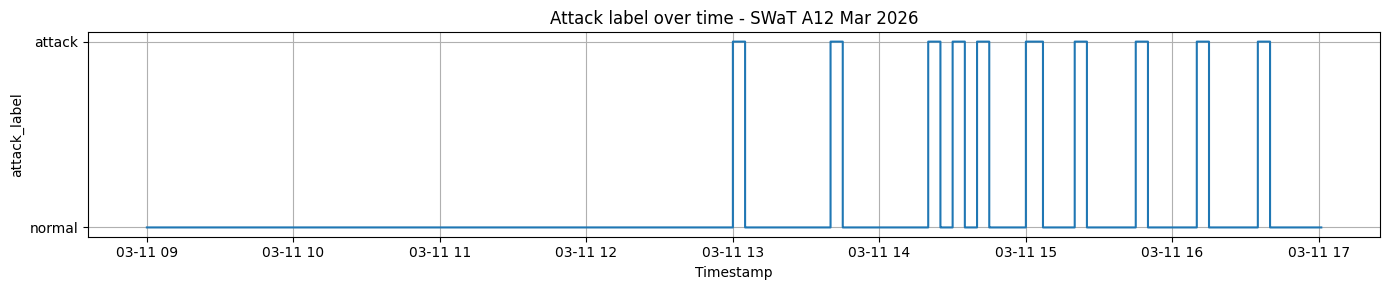

In [12]:
plt.figure(figsize=(14, 3))
plt.plot(df_labeled["t_stamp"], df_labeled["attack_label"], drawstyle="steps-post")
plt.title("Attack label over time - SWaT A12 Mar 2026")
plt.xlabel("Timestamp")
plt.ylabel("attack_label")
plt.yticks([0, 1], ["normal", "attack"])
plt.grid(True)
plt.tight_layout()
plt.show()


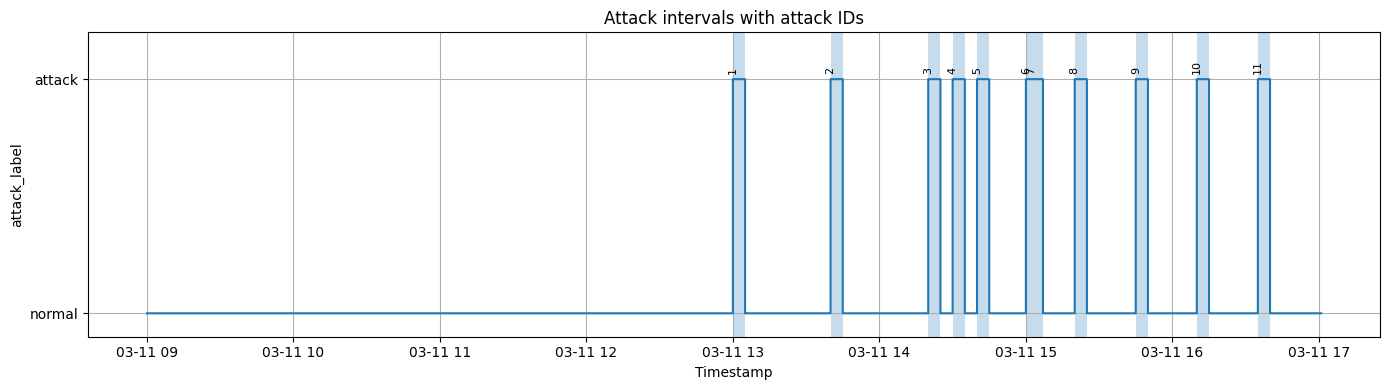

In [13]:
plt.figure(figsize=(14, 4))

for _, row in schedule_parsed.iterrows():
    plt.axvspan(row["start_datetime"], row["end_datetime"], alpha=0.25)
    plt.text(
        row["start_datetime"],
        1.02,
        str(row["attack_id"]),
        rotation=90,
        va="bottom",
        ha="center",
        fontsize=8
    )

plt.plot(df_labeled["t_stamp"], df_labeled["attack_label"], drawstyle="steps-post")
plt.title("Attack intervals with attack IDs")
plt.xlabel("Timestamp")
plt.ylabel("attack_label")
plt.yticks([0, 1], ["normal", "attack"])
plt.ylim(-0.1, 1.2)
plt.grid(True)
plt.tight_layout()
plt.show()


## 10. Inspección rápida de targets primarios

Esta sección no modifica el dataset. Solo ayuda a revisar que las variables objetivo de cada ataque existan o tengan equivalentes en las columnas del CSV.

Por ejemplo, un target `MV501–504` puede corresponder a `MV501.Status`, `MV502.Status`, `MV503.Status`, `MV504.Status`.


In [14]:
def normalize_dash(text):
    if pd.isna(text):
        return ""
    return str(text).replace("–", "-").replace("—", "-").strip()

def expand_target_token(token):
    token = normalize_dash(token).strip()

    # Ejemplo: MV501-504 -> MV501, MV502, MV503, MV504
    m = re.match(r"^([A-Za-z]+)(\d+)-(\d+)$", token)
    if m:
        prefix, start_num, end_num = m.groups()
        start_num_int = int(start_num)
        end_num_int = int(end_num)
        width = len(start_num)

        if end_num_int >= start_num_int:
            return [f"{prefix}{i:0{width}d}" for i in range(start_num_int, end_num_int + 1)]

    return [token]

def parse_primary_targets(targets):
    targets = normalize_dash(targets)
    parts = [p.strip() for p in re.split(r",|&", targets) if p.strip()]
    expanded = []

    for part in parts:
        expanded.extend(expand_target_token(part))

    return expanded

target_rows = []

for _, row in schedule_parsed.iterrows():
    targets = parse_primary_targets(row["primary_targets"])

    for target in targets:
        matching_cols = [
            c for c in df_labeled.columns
            if c == target or c.startswith(target + ".") or c.startswith(target + "_")
        ]

        target_rows.append({
            "attack_id": row["attack_id"],
            "target": target,
            "matching_columns": matching_cols,
            "n_matching_columns": len(matching_cols)
        })

target_check_df = pd.DataFrame(target_rows)
display(target_check_df)


,attack_id,target,matching_columns,n_matching_columns
0,1,MV501,[MV501.Status],1
1,1,MV502,[MV502.Status],1
2,1,MV503,[MV503.Status],1
3,1,MV504,[MV504.Status],1
4,2,MV101,[MV101.Status],1
5,2,P101,[P101.Status],1
6,2,P102,[P102.Status],1
7,3,P201-P206,[],0
8,3,MV201,[MV201.Status],1
9,4,LIT101,[LIT101.Pv],1


## 11. Guardar dataset etiquetado

Se guarda:

1. Dataset etiquetado completo.
2. Cronograma parseado.
3. Metadata de etiquetado para trazabilidad.


In [15]:
# Convertir timestamps a formato ISO-like legible antes de guardar.
# pandas los guardará como strings en CSV.

df_labeled.to_csv(LABELED_OUTPUT_PATH, index=False)
schedule_parsed.to_csv(SCHEDULE_OUTPUT_PATH, index=False)

metadata = {
    "raw_data_path": str(RAW_DATA_PATH),
    "attack_schedule_path": str(ATTACK_SCHEDULE_PATH),
    "labeled_output_path": str(LABELED_OUTPUT_PATH),
    "schedule_output_path": str(SCHEDULE_OUTPUT_PATH),
    "dataset_start": str(df_labeled["t_stamp"].min()),
    "dataset_end": str(df_labeled["t_stamp"].max()),
    "total_rows": int(len(df_labeled)),
    "normal_rows": normal_rows,
    "attack_rows": attack_rows,
    "attack_ratio": float(attack_rows / total_rows),
    "interval_convention": "start <= t_stamp < end",
    "n_attacks": int(len(schedule_parsed)),
    "matched_rows_by_attack": matched_rows_df.to_dict(orient="records")
}

with open(METADATA_OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False, default=str)

print("Saved labeled dataset to:", LABELED_OUTPUT_PATH)
print("Saved parsed schedule to:", SCHEDULE_OUTPUT_PATH)
print("Saved metadata to:", METADATA_OUTPUT_PATH)


Saved labeled dataset to: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\data\clean\SWaT.A12_OTDataset_Mar_26\11-Mar-2026_0900_1700_labeled.csv
Saved parsed schedule to: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\data\clean\SWaT.A12_OTDataset_Mar_26\ataques_a12_data_parsed.csv
Saved metadata to: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\data\clean\SWaT.A12_OTDataset_Mar_26\labeling_metadata.json


## 12. Verificación final de lectura

Se recarga el CSV guardado para confirmar que el archivo existe y conserva las columnas de etiqueta.


In [16]:
check_df = pd.read_csv(LABELED_OUTPUT_PATH, nrows=5)
display(check_df.head())

expected_label_cols = [
    "attack_label",
    "attack_id",
    "attack_name",
    "attack_targets",
    "attack_start_time",
    "attack_end_time"
]

missing_after_save = [c for c in expected_label_cols if c not in check_df.columns]

if missing_after_save:
    raise ValueError(f"Missing label columns after saving: {missing_after_save}")

print("Final verification OK.")


,t_stamp,P1_STATE,LIT101.Pv,FIT101.Pv,MV101.Status,P101.Status,P102.Status,P2_STATE,FIT201.Pv,AIT201.Pv,AIT202.Pv,AIT203.Pv,MV201.Status,P201.Status,P202.Status,P203.Status,P204.Status,P205.Status,P206.Status,P207.Status,P208.Status,LS201.Alarm,LS202.Alarm,LSL203.Alarm,LSLL203.Alarm,P3_STATE,AIT301.Pv,AIT302.Pv,AIT303.Pv,LIT301.Pv,FIT301.Pv,DPIT301.Pv,MV301.Status,MV302.Status,MV303.Status,MV304.Status,P301.Status,P302.Status,PSH301.Alarm,DPSH301.Alarm,P4_STATE,LIT401.Pv,FIT401.Pv,AIT401.Pv,AIT402.Pv,P401.Status,P402.Status,P403.Status,P404.Status,UV401.Status,LS401.Alarm,P5_STATE,FIT501.Pv,FIT502.Pv,FIT503.Pv,FIT504.Pv,AIT501.Pv,AIT502.Pv,AIT503.Pv,AIT504.Pv,PIT501.Pv,PIT502.Pv,PIT503.Pv,P501.Status,P501.Speed,P502.Status,P502.Speed,MV501.Status,MV502.Status,MV503.Status,MV504.Status,PSH501.Alarm,PSL501.Alarm,P6_STATE,LIT601.Pv,LIT602.Pv,FIT601.Pv,FIT602.Pv,P601.Status,P602.Status,P603.Status,LSH601.Alarm,LSL601.Alarm,LSH602.Alarm,LSL602.Alarm,LSH603.Alarm,LSL603.Alarm,attack_label,attack_id,attack_name,attack_targets,attack_start_time,attack_end_time
0,2026-03-11 09:00:00,1,809.6666,0.0,1,1,1,1,0.0,99.36555,9.998270,152.525,1,1,1,1,1,1,1,1,1,Inactive,Inactive,Inactive,Active,1,7.714322,194.711563,31.01991,655.480957,0.0,3.617389,1,1,1,1,1,1,Bad Input,Bad Input,1,1006.39581,0.0,0.0,203.896439,1,1,1,1,1,Inactive,1,0.002692,0.001793,0.001408,0.0,8.918098,305.152527,163.195328,29.838503,9.068188,0.0,6.777109,1,0.0,1,0.0,1,1,1,1,Bad Input,Bad Input,1,341.643158,548.769531,0.0,0.884247,1,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active,0,NaN,NaN,NaN,NaN,NaN
1,2026-03-11 09:00:01,1,809.6666,0.0,1,1,1,1,0.0,99.36555,9.994104,152.525,1,1,1,1,1,1,1,1,1,Inactive,Inactive,Inactive,Active,1,7.714322,194.711563,31.01991,655.480957,0.0,3.617389,1,1,1,1,1,1,Bad Input,Bad Input,1,1006.43427,0.0,0.0,203.896439,1,1,1,1,1,Inactive,1,0.002692,0.001793,0.001408,0.0,8.919380,305.152527,163.195328,29.838503,9.068188,0.0,6.777109,1,0.0,1,0.0,1,1,1,1,Bad Input,Bad Input,1,341.643158,548.769531,0.0,0.897863,1,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active,0,NaN,NaN,NaN,NaN,NaN
2,2026-03-11 09:00:02,1,809.6666,0.0,1,1,1,1,0.0,99.36555,9.988977,152.525,1,1,1,1,1,1,1,1,1,Inactive,Inactive,Inactive,Active,1,7.714322,194.711563,31.01991,655.480957,0.0,3.617389,1,1,1,1,1,1,Bad Input,Bad Input,1,1006.20355,0.0,0.0,203.896439,1,1,1,1,1,Inactive,1,0.002692,0.001793,0.001408,0.0,8.921623,305.152527,163.195328,29.838503,9.068188,0.0,6.777109,1,0.0,1,0.0,1,1,1,1,Bad Input,Bad Input,1,341.739300,548.769531,0.0,0.897863,1,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active,0,NaN,NaN,NaN,NaN,NaN
3,2026-03-11 09:00:03,1,809.6666,0.0,1,1,1,1,0.0,99.36555,9.986094,152.525,1,1,1,1,1,1,1,1,1,Inactive,Inactive,Inactive,Active,1,7.714322,194.711563,31.01991,655.480957,0.0,3.617389,1,1,1,1,1,1,Bad Input,Bad Input,1,1006.35736,0.0,0.0,203.896439,1,1,1,1,1,Inactive,1,0.002692,0.001793,0.001408,0.0,8.924828,305.152527,163.195328,29.838503,9.068188,0.0,6.777109,1,0.0,1,0.0,1,1,1,1,Bad Input,Bad Input,1,341.867462,548.769531,0.0,0.895140,1,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active,0,NaN,NaN,NaN,NaN,NaN
4,2026-03-11 09:00:04,1,810.2162,0.0,1,1,1,1,0.0,99.36555,9.982569,152.525,1,1,1,1,1,1,1,1,1,Inactive,Inactive,Inactive,Active,1,7.714322,194.711563,31.01991,654.960266,0.0,3.617389,1,1,1,1,1,1,Bad Input,Bad Input,1,1006.62653,0.0,0.0,203.896439,1,1,1,1,1,Inactive,1,0.002692,0.001793,0.001408,0.0,8.927071,305.152527,163.195328,29.838503,9.068188,0.0,6.777109,1,0.0,1,0.0,1,1,1,1,Bad Input,Bad Input,1,341.867462,548.769531,0.0,0.896582,1,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active,0,NaN,NaN,NaN,NaN,NaN


Final verification OK.


## Resultado

El archivo etiquetado queda listo para el notebook de validación externa.

Siguiente paso recomendado:

1. Cargar `11-Mar-2026_0900_1700_labeled.csv`.
2. Aplicar el mismo preprocesamiento del detector Conv1D.
3. Construir ventanas con `window_size=60` y `stride=5`.
4. Etiquetar cada ventana usando `attack_label`.
5. Evaluar los modelos entrenados en los escenarios:
   - real only,
   - synthetic only,
   - real + synthetic.
